In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gaiamock import gaiamock_var  as gm
from gaiamock import gaiamock_mod  as gmo
from gaiamock import variability_tool as vt
import pandas as pd
path_to_data="/Users/giorio/Dropbox/Work_Project/RRLgaiamock/paper/data/healpix_scans/healpix_scans"
gm.set_healpyx_table_path(path_to_data)
gmo.set_healpyx_table_path(path_to_data)
CFUNC= gm.read_in_C_functions()

RUWE 1.1529453718687206
RUWE 1.6032339848756032


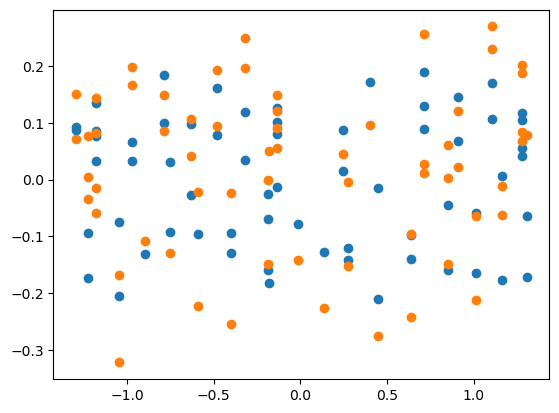

In [3]:
#Check if single is working
ra=230
dec=35
pmra=0
pmdec=0
parallax=0.2
phot_g_mean_mag=14

#JDB_TCB = t_gaia + 2455197.5

t,psi,plx, Lambda, error = gm.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag
                                   )
print("RUWE",gm.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)

varmodel=vt.SimpleSinusoidal(amp=0.3,period=0.27,fchrom=0.3,relative_norm=False)
t,psi,plx, Lambda, error = gm.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag,
                                    variability_tool=varmodel
                                   )
print("RUWE",gm.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)

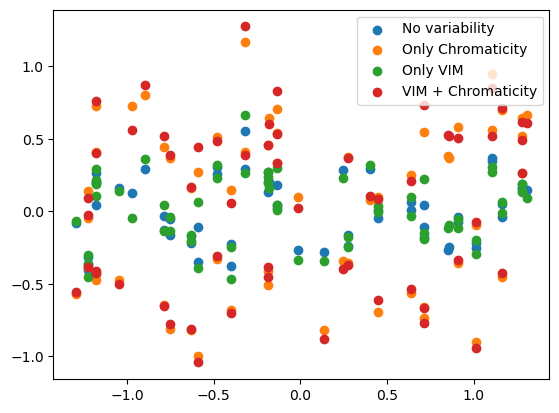

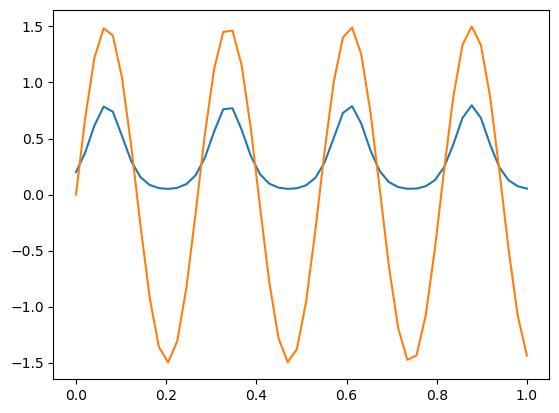

[2456916.26319825 2456940.46642838 2456940.64252698 2456940.71658839
 2456958.65020021 2456958.72426248 2456958.90036306 2456958.97442657
 2457006.96093664 2457034.88124837 2457062.19619709 2457101.0800019
 2457101.15406819 2457114.40842534 2457114.58453068 2457159.51908805
 2457159.59315017 2457173.09709049 2457173.27318602 2457214.22756715
 2457214.30162599 2457242.96650862 2457243.04056732 2457272.70803916
 2457272.78209837 2457321.51658472 2457321.69268817 2457321.76675165
 2457321.94285222 2457339.70079313 2457339.77485729 2457340.02502798
 2457383.50971987 2457438.16804298 2457479.19318218 2457490.19776746
 2457490.3738709  2457535.55922155 2457551.81178573 2457551.8858455
 2457623.00842048 2457623.08247984 2457650.08046281 2457650.25655739
 2457650.33061869 2457700.99284464 2457701.24301308 2457721.25028729
 2457721.32435303 2457759.98421725 2457760.05828506 2457792.46444908
 2457792.5385169  2457813.84398977 2457814.02010025 2457856.4649215
 2457856.53898662 2457856.7150903  24

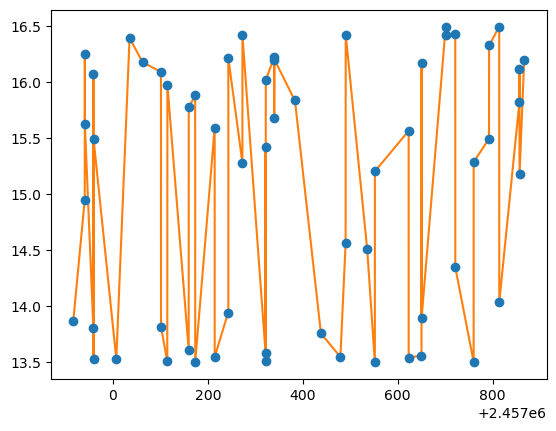

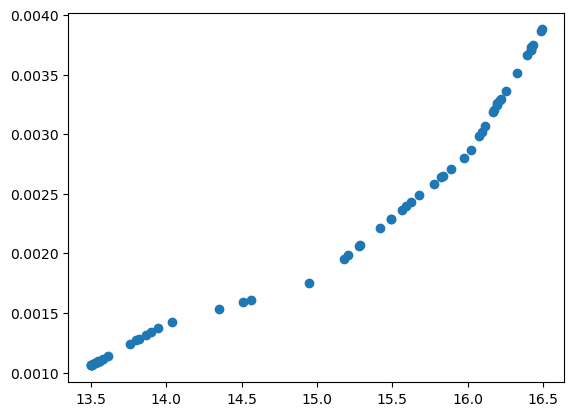

In [18]:
#Try now binary
ra=230
dec=35
pmra=0
pmdec=0
parallax=0.2
phot_g_mean_mag=15
m1=0.5
m2=1
period=1000
Tp=0
ecc=0
omega=0
w=0
f=0.2
inc=0

np.random.seed(10)
t,psi,plx, Lambda, error, G_obs, G_err = gm.predict_astrometry_luminous_binary(ra=ra, dec=dec, 
                                       parallax=parallax, 
                                       pmra=pmra, pmdec=pmdec, 
                                       m1=m1, m2=m2, 
                                       period=period, Tp=Tp, ecc=ecc, omega=omega, inc=inc, w=0, 
                                       phot_g_mean_mag=phot_g_mean_mag, 
                                       f=f, data_release="dr3", 
                                       c_funcs=CFUNC, 
                                       do_blending_noise = False, 
                                       reject_10_percent = True, 
                                       variability_tool=vt.VariabilityTool(0.))
plt.scatter(t,Lambda,label="No variability")

class Sinusoidal(vt.VariabilityTool):
    
    def __init__(self, amp_g, amp_c, period,fchrom,relative_norm=True):
        super().__init__(fchrom=fchrom,relative_norm=relative_norm)
        self.amp_g  = amp_g
        self.amp_c  = amp_c
        self.period = period

    def __call__(self, time):
        return self.amp_c * np.sin(2 * np.pi * time / self.period)
    
    def g_lcurve_normalised(self,time):
        return self.amp_g * np.sin(2 * np.pi * time / self.period)


np.random.seed(10)
varmodel=Sinusoidal(amp_g=0., amp_c=1,period=0.27,fchrom=0.65,relative_norm=False)
t,psi,plx, Lambda, error, G_obs, G_err = gm.predict_astrometry_luminous_binary(ra=ra, dec=dec, 
                                       parallax=parallax, 
                                       pmra=pmra, pmdec=pmdec, 
                                       m1=m1, m2=m2, 
                                       period=period, Tp=Tp, ecc=ecc, omega=omega, inc=inc, w=0, 
                                       phot_g_mean_mag=phot_g_mean_mag, 
                                       f=f, data_release="dr3", 
                                       c_funcs=CFUNC, 
                                       do_blending_noise = False, 
                                       reject_10_percent = True, 
                                       variability_tool=varmodel)
plt.scatter(t,Lambda,label="Only Chromaticity")

np.random.seed(10)
varmodel=Sinusoidal(amp_g=1.5, amp_c=0.,period=0.27,fchrom=0.65,relative_norm=False)
t,psi,plx, Lambda, error, G_obs, G_err = gm.predict_astrometry_luminous_binary(ra=ra, dec=dec, 
                                       parallax=parallax, 
                                       pmra=pmra, pmdec=pmdec, 
                                       m1=m1, m2=m2, 
                                       period=period, Tp=Tp, ecc=ecc, omega=omega, inc=inc, w=0, 
                                       phot_g_mean_mag=phot_g_mean_mag, 
                                       f=f, data_release="dr3", 
                                       c_funcs=CFUNC, 
                                       do_blending_noise = False, 
                                       reject_10_percent = True, 
                                       variability_tool=varmodel)
plt.scatter(t,Lambda,label="Only VIM")

np.random.seed(10)
varmodel=Sinusoidal(amp_g=1.5, amp_c=1.0,period=0.27,fchrom=0.65,relative_norm=False)
t,psi,plx, Lambda, error, G_obs, G_err = gm.predict_astrometry_luminous_binary(ra=ra, dec=dec, 
                                       parallax=parallax, 
                                       pmra=pmra, pmdec=pmdec, 
                                       m1=m1, m2=m2, 
                                       period=period, Tp=Tp, ecc=ecc, omega=omega, inc=inc, w=0, 
                                       phot_g_mean_mag=phot_g_mean_mag, 
                                       f=f, data_release="dr3", 
                                       c_funcs=CFUNC, 
                                       do_blending_noise = False, 
                                       reject_10_percent = True, 
                                       variability_tool=varmodel)
plt.scatter(t,Lambda,label="VIM + Chromaticity")
plt.legend()
plt.show()

xx=np.linspace(0,1)
plt.plot(xx,f*10**(0.4*varmodel.g_lcurve_normalised(xx)))
plt.plot(xx,varmodel.g_lcurve_normalised(xx))
plt.show()

bjd=gm.get_jd_from_tast_yr(t, data_release="dr3")
print(bjd)

plt.errorbar(bjd, G_obs,G_err,fmt="o")
plt.plot(bjd,varmodel.g_lcurve_normalised(bjd)+phot_g_mean_mag)
plt.show()
plt.scatter(G_obs,G_err)